In [72]:
# ----- voglio confrontare le matrici che portano a comportamenti opposti
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from neuron.rxdtests.tests.hh import alpha
from pyqtgraph.examples.PColorMeshItem import density

from  Test_function_26_08_2026 import get_activated_spine_idx
import flammkuchen as fl
import seaborn as sns
# ----- devo caricare le matrici
yymmdd = '240813'
cell = 'cell0001'

spine_type_BLA = 'is_BLA'
spine_type_CA3 = 'is_CA3'

main_matrix_ids = ['M1','M2','M3','M5','M6','M8', 'M10']
main_matrix_data = {}
for main_matrix_id in main_matrix_ids:
    main_matrix_path = Path("D:/") / ('inputs') / f"{yymmdd}_{cell}_{main_matrix_id}_input_matrix"
    X_exc_path = Path(main_matrix_path)/('sim_0000000.npy')

    X_min = 0.0
    X_max = 0.0007
    X_exc_uint8 = np.load(X_exc_path)

    X_conv = X_exc_uint8.astype(np.float64) / 255.0 * (X_max - X_min) + X_min
    X_exc = np.round(X_conv,5)

    main_matrix_data[(main_matrix_id)] = []
    main_matrix_data[(main_matrix_id)].append(X_exc)

exp_data_path = ("D:/test_save_old/" + yymmdd + "_" + cell + "_morph_and_spines.h5")
exp_dataset = fl.load(exp_data_path)

### M2 ed M3 ---> distribuzione sperimentale spostata a sinistra

### M1 e M6 ---> distribuzione sperimentale spostata a destra

### M8 ---> distribuzione sperimentale quasi al centro

In [73]:
M1 = np.array(main_matrix_data['M1'])
M2 = np.array(main_matrix_data['M2'])
M3 = np.array(main_matrix_data['M3'])
M6 = np.array(main_matrix_data['M6'])
M8 = np.array(main_matrix_data['M8'])
M5 = np.array(main_matrix_data['M5'])
M10 = np.array(main_matrix_data['M10'])


In [74]:
#M1.shape
# X_exc.shape
type(M1[0])

numpy.ndarray

In [75]:
len(M1[0]) # sono 1344 spine

1344

In [76]:
len(M1[0][0]) # ogni spina ha 800 elementi, sono i pesi ad ogni ms, la durata e' 800 ms

800

In [77]:
#num_spines, sim_T_ms = M1[0].shape


In [78]:
matr_1 = M1[0]

### Matrici M1 ed M2

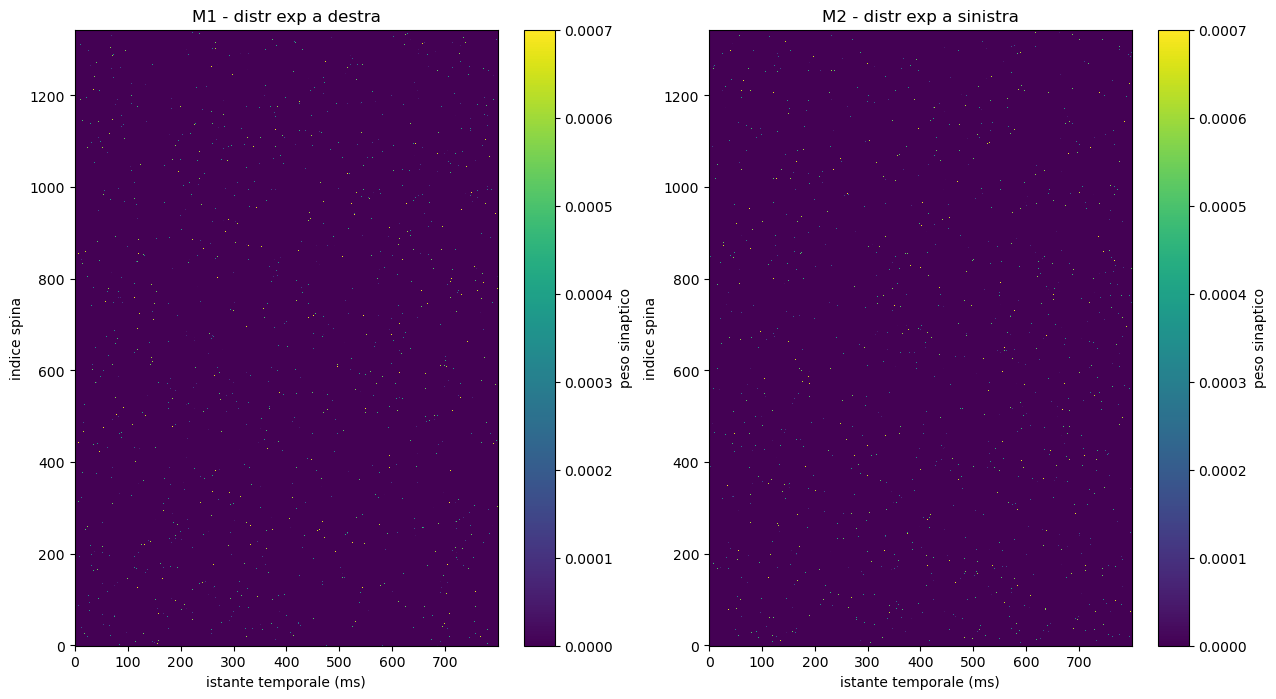

In [79]:
import matplotlib.pyplot as plt
X = M1[0]
fig, ax = plt.subplots(1,2, figsize=(15, 8))
im0 = ax[0].imshow(M1[0], aspect='auto', cmap='viridis', interpolation='none',origin='lower',vmin=0, vmax=0.0007)
ax[0].set_xlabel('istante temporale (ms)')
ax[0].set_ylabel('indice spina')
ax[0].set_title('M1 - distr exp a destra')
fig.colorbar(im0, ax=ax[0],label='peso sinaptico')

im1 = ax[1].imshow(M2[0], aspect='auto', cmap='viridis', interpolation='none',origin='lower',vmin=0, vmax=0.0007)
ax[1].set_xlabel('istante temporale (ms)')
ax[1].set_ylabel('indice spina')
ax[1].set_title('M2 - distr exp a sinistra')
fig.colorbar(im1, ax=ax[1],label='peso sinaptico')
plt.show()

In [80]:
# ----- overall rms
rms_M1 = np.sqrt(np.mean(M1[0]**2))
rms_M2 = np.sqrt(np.mean(M2[0]**2))

print(rms_M1,rms_M2)

2.5119968845948605e-05 2.4657452329004776e-05


In [81]:
# ----- rmse
rmse = np.sqrt(np.mean((M1[0] - M2[0])**2))
print(rmse)

3.5125767869932474e-05


## rms per spina per M1 e per M2

In [82]:
rms_per_spina_M1 = np.sqrt(np.mean(M1[0]**2, axis=1))    # un valore per ciascuna spina (riga)
#rms_per_istante = np.sqrt(np.mean(A**2, axis=0))  # un valore per ciascun istante temporale (colonna)

rms_per_spina_M2 = np.sqrt(np.mean(M2[0]**2, axis=1))    # un valore per ciascuna spina (riga)

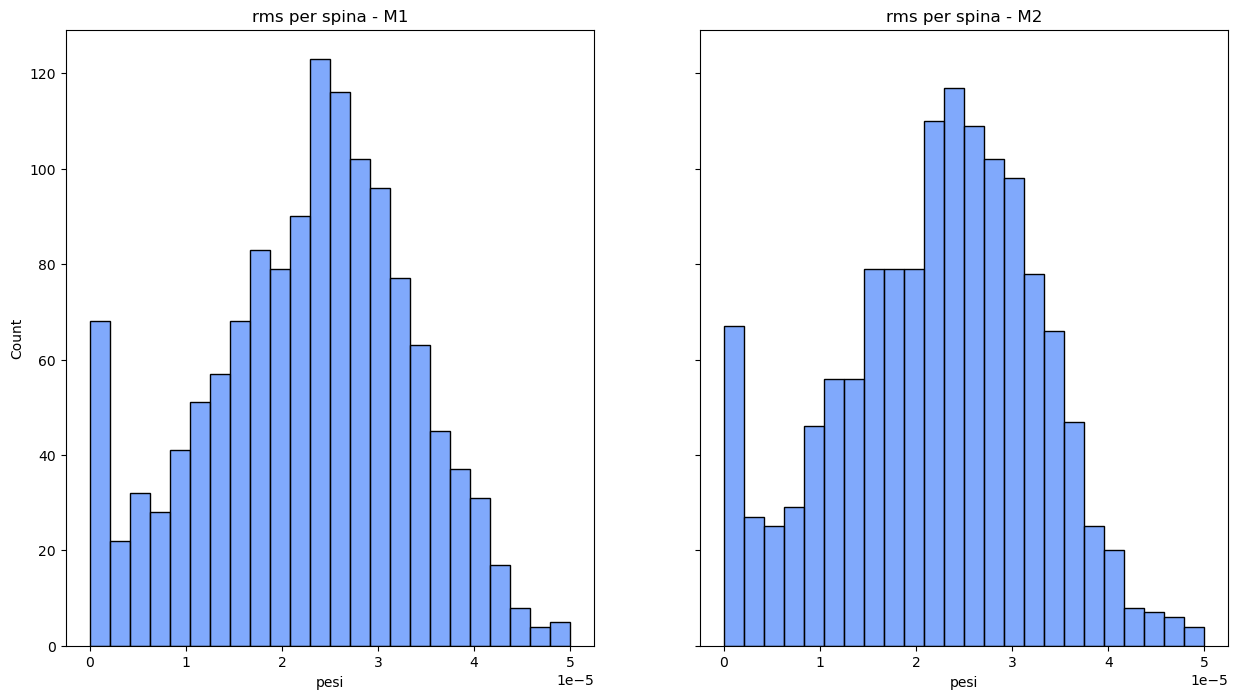

In [83]:
bins_n= np.linspace(0,5e-5,25)
fig, ax = plt.subplots(1,2, figsize=(15, 8),
                       sharex=True, sharey=True)
#ax[0].hist(rms_per_spina_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_per_spina_M2, bins=bins_n, edgecolor='black')
sns.histplot(
    rms_per_spina_M1,
    bins=bins_n,
    edgecolor='black',
    ax=ax[0]
)

sns.histplot(
    rms_per_spina_M2,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1]
)
ax[0].set_title('rms per spina - M1')
ax[1].set_title('rms per spina - M2')

ax[0].set_xlabel('pesi')
ax[1].set_xlabel('pesi')

plt.show()

In [84]:
BLA_spine_idx_exp, non_BLA_spine_idx_exp = get_activated_spine_idx(
                exp_dataset['spines_df'], spine_type_BLA)
CA3_spine_idx_exp, non_CA3_spine_idx_exp = get_activated_spine_idx(
                exp_dataset['spines_df'], spine_type_CA3)

In [85]:
BLA_spine_idx_exp

array([  73,  132,  249,  255,  437,  493,  501,  508,  512,  613,  616,
        636,  794,  818,  835,  863,  981,  999, 1021, 1035, 1057, 1073,
       1113, 1209, 1213, 1222, 1224, 1253, 1291])

In [86]:
rms_BLA_M1 = np.sqrt(np.mean(M1[0][BLA_spine_idx_exp, :]**2,axis=1)) # ottengo un valore per ciascuna spina, considera gli elementi su una riga quindi che fanno riferimento ad una spina
rms_non_BLA_M1 = np.sqrt(np.mean(M1[0][non_BLA_spine_idx_exp, :]**2,axis=1))

rms_BLA_M2 = np.sqrt(np.mean(M2[0][BLA_spine_idx_exp, :]**2,axis=1))
rms_non_BLA_M2 = np.sqrt(np.mean(M2[0][non_BLA_spine_idx_exp, :]**2,axis=1))

rms_BLA_M3 = np.sqrt(np.mean(M3[0][BLA_spine_idx_exp, :]**2,axis=1))
rms_non_BLA_M3 = np.sqrt(np.mean(M3[0][non_BLA_spine_idx_exp, :]**2,axis=1))

rms_BLA_M6 = np.sqrt(np.mean(M6[0][BLA_spine_idx_exp, :]**2,axis=1))
rms_non_BLA_M6 = np.sqrt(np.mean(M6[0][non_BLA_spine_idx_exp, :]**2,axis=1))

rms_BLA_M8 = np.sqrt(np.mean(M8[0][BLA_spine_idx_exp, :]**2,axis=1))
rms_non_BLA_M8 = np.sqrt(np.mean(M8[0][non_BLA_spine_idx_exp, :]**2,axis=1))

rms_BLA_M5 = np.sqrt(np.mean(M5[0][BLA_spine_idx_exp, :]**2,axis=1))
rms_non_BLA_M5 = np.sqrt(np.mean(M5[0][non_BLA_spine_idx_exp, :]**2,axis=1))

#print(f"RMS spine BLA attivate: {rms_BLA_attivate:.6e}")
#print(f"RMS spine BLA non attivate: {rms_BLA_non_attivate:.6e}")

### RMS per spine BLA, divise per main matrix che portano ad andamenti simili delle distanze

### i plot sono accoppiati per main matrix che portano ad andamenti simili

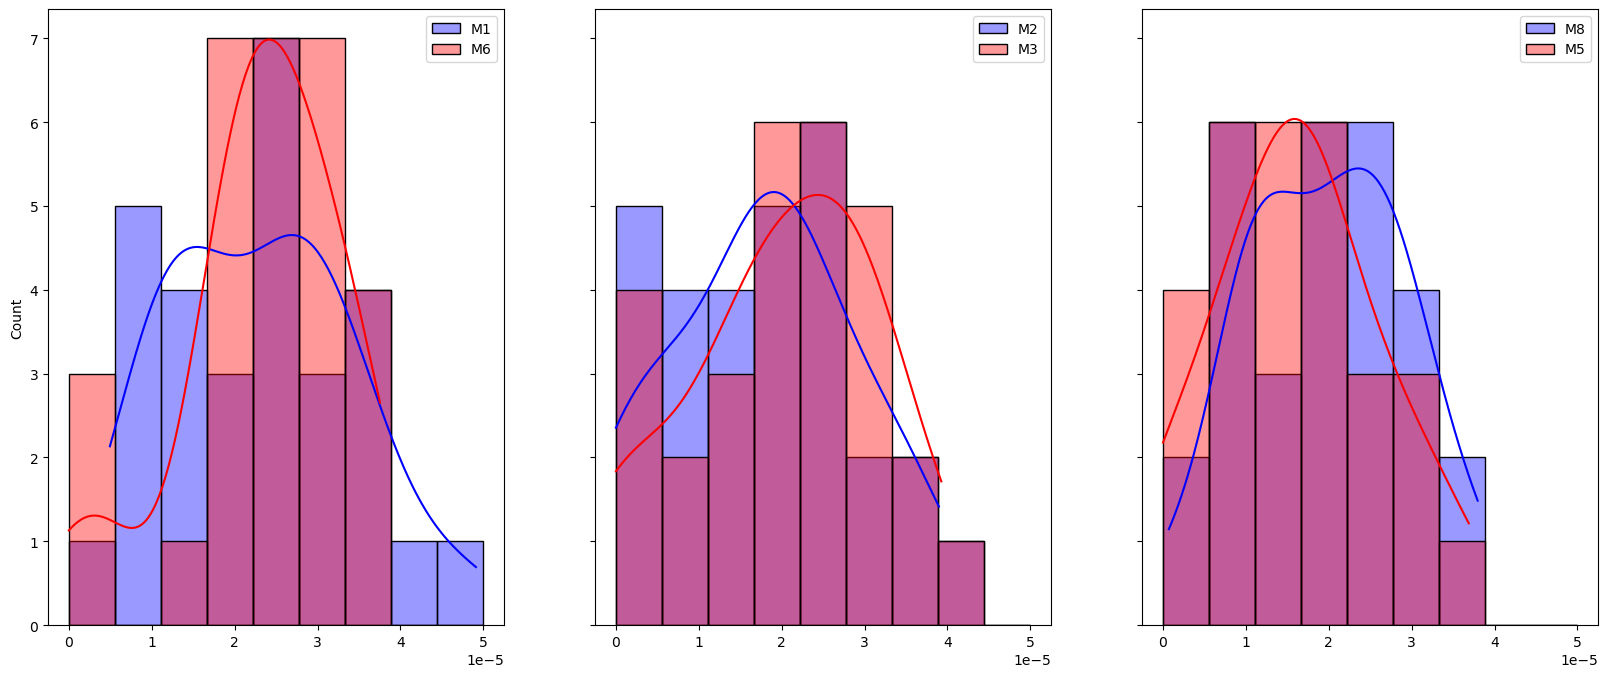

In [117]:
bins_n= np.linspace(0,5e-5,10)
fig, ax = plt.subplots(1,3, figsize=(20, 8),sharex=True,sharey=True)

sns.histplot(
    rms_BLA_M1,
    bins=bins_n,
    #edgecolor='red',
    color='blue',
    ax=ax[0],
    label='M1',
    alpha=0.4,
    kde=True
    #stat='probability'
)

sns.histplot(
    rms_BLA_M6,
    bins=bins_n,
    #edgecolor='black',
    color='red',
    ax=ax[0],
    label='M6',
    alpha=0.4,
    kde=True
    #stat='probability'
)
sns.histplot(
    rms_BLA_M2,
    bins=bins_n,
    #edgecolor='red',
    color='blue',
    ax=ax[1],
    label='M2',
    alpha=0.4,
    kde=True
    #stat='probability'
)

sns.histplot(
    rms_BLA_M3,
    bins=bins_n,
    #edgecolor='black',
    color='red',
    ax=ax[1],
    label='M3',
    alpha=0.4,
    kde=True
    #stat='probability'
)
sns.histplot(
    rms_BLA_M8,
    bins=bins_n,
    #edgecolor='red',
    color='blue',
    alpha=0.4,
    label='M8',
    ax=ax[2],
    kde=True
    #stat='density'
)
sns.histplot(
    rms_BLA_M5,
    bins=bins_n,
    #edgecolor='red',
    color='red',
    alpha=0.4,
    label='M5',
    ax=ax[2],
    kde=True
    #stat='density'
)

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

### da non considerare, ripetizione di quelli sopra

In [88]:
'''
bins_n= np.linspace(0,5e-5,10)
fig, ax = plt.subplots(2,5, figsize=(15, 8))
#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')

sns.histplot(
    rms_BLA_M1,
    bins=bins_n,
    #edgecolor='red',
    color='blue',
    ax=ax[0,0],
    label='M1',
    alpha=0.4,
    kde=True
    #stat='probability'
)

sns.histplot(
    rms_BLA_M6,
    bins=bins_n,
    #edgecolor='black',
    color='red',
    ax=ax[0,0],
    label='M6',
    alpha=0.4,
    kde=True
    #stat='probability'
)
sns.histplot(
    rms_BLA_M2,
    bins=bins_n,
    #edgecolor='red',
    color='blue',
    ax=ax[0,1],
    label='M2',
    alpha=0.4,
    kde=True
    #stat='probability'
)

sns.histplot(
    rms_BLA_M3,
    bins=bins_n,
    #edgecolor='black',
    color='red',
    ax=ax[0,1],
    label='M3',
    alpha=0.4,
    kde=True
    #stat='probability'
)
sns.histplot(
    rms_BLA_M8,
    bins=bins_n,
    #edgecolor='red',
    color='blue',
    alpha=0.4,
    label='M8',
    ax=ax[0,2],
    kde=True
    #stat='density'
)
sns.histplot(
    rms_BLA_M5,
    bins=bins_n,
    #edgecolor='red',
    color='red',
    alpha=0.4,
    label='M5',
    ax=ax[0,2],
    kde=True
    #stat='density'
)

sns.histplot(
    rms_non_BLA_M1,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,0]
    #stat='density'
)

sns.histplot(
    rms_non_BLA_M2,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,1]
    #stat='density'
)




sns.histplot(
    rms_non_BLA_M3,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,2]
    #stat='density'
)

sns.histplot(
    rms_non_BLA_M6,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,3]
    #stat='density'
)



sns.histplot(
    rms_non_BLA_M8,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,4]
    #stat='density'
)


ax[0,0].set_ylim([0,8])
ax[0,1].set_ylim([0,8])
ax[0,2].set_ylim([0,8])
ax[0,3].set_ylim([0,8])
ax[0,4].set_ylim([0,8])


ax[0,0].set_title('rms spine BLA')
ax[0,1].set_title('rms spine BLA ')
ax[1,0].set_title('rms spine non-BLA per M1')
ax[1,1].set_title('rms spine non-BLA per M2')

ax[0,2].set_title('rms spine BLA')
#ax[0,3].set_title('rms spine BLA per M6')
#ax[0,4].set_title('rms spine BLA per M8')

ax[0,0].legend()
ax[0,1].legend()
ax[0,2].legend()
#ax[0].set_xlabel('pesi')
#ax[1].set_xlabel('pesi')
plt.show()
'''

"\nbins_n= np.linspace(0,5e-5,10)\nfig, ax = plt.subplots(2,5, figsize=(15, 8))\n#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')\n#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')\n\nsns.histplot(\n    rms_BLA_M1,\n    bins=bins_n,\n    #edgecolor='red',\n    color='blue',\n    ax=ax[0,0],\n    label='M1',\n    alpha=0.4,\n    kde=True\n    #stat='probability'\n)\n\nsns.histplot(\n    rms_BLA_M6,\n    bins=bins_n,\n    #edgecolor='black',\n    color='red',\n    ax=ax[0,0],\n    label='M6',\n    alpha=0.4,\n    kde=True\n    #stat='probability'\n)\nsns.histplot(\n    rms_BLA_M2,\n    bins=bins_n,\n    #edgecolor='red',\n    color='blue',\n    ax=ax[0,1],\n    label='M2',\n    alpha=0.4,\n    kde=True\n    #stat='probability'\n)\n\nsns.histplot(\n    rms_BLA_M3,\n    bins=bins_n,\n    #edgecolor='black',\n    color='red',\n    ax=ax[0,1],\n    label='M3',\n    alpha=0.4,\n    kde=True\n    #stat='probability'\n)\nsns.histplot(\n    rms_BLA_M8,\n    bins=bin

### RMS su spine selezionate

In [96]:
# ----- rms su spine selezionate

rms_all_BLA_M1 = np.sqrt(np.mean(M1[0][BLA_spine_idx_exp, :]**2)) # un valore solo, considerando tutte le spine BLA
rms_all_non_BLA_M1 = np.sqrt(np.mean(M1[0][non_BLA_spine_idx_exp, :]**2)) # un valore solo, considerando tutte le spine non-BLA

rms_all_BLA_M2 = np.sqrt(np.mean(M2[0][BLA_spine_idx_exp, :]**2))
rms_all_non_BLA_M2 = np.sqrt(np.mean(M2[0][non_BLA_spine_idx_exp, :]**2))

rms_all_BLA_M3 = np.sqrt(np.mean(M3[0][BLA_spine_idx_exp, :]**2))
rms_all_non_BLA_M3 = np.sqrt(np.mean(M3[0][non_BLA_spine_idx_exp, :]**2))

rms_all_BLA_M6 = np.sqrt(np.mean(M6[0][BLA_spine_idx_exp, :]**2))
rms_all_non_BLA_M6 = np.sqrt(np.mean(M6[0][non_BLA_spine_idx_exp, :]**2))

rms_all_BLA_M8 = np.sqrt(np.mean(M8[0][BLA_spine_idx_exp, :]**2))
rms_all_non_BLA_M8 = np.sqrt(np.mean(M8[0][non_BLA_spine_idx_exp, :]**2))



print(f"RMS spine BLA M1: {rms_all_BLA_M1:.6e} ----- RMS spine BLA M6: {rms_all_BLA_M6:.6e}")
print(f"RMS spine non BLA M1: {rms_all_non_BLA_M1:.6e}")

print(f"RMS spine BLA M2: {rms_all_BLA_M2:.6e}")
print(f"RMS spine non BLA M2: {rms_all_non_BLA_M2:.6e}",'\n')

print(f"RMS spine BLA M8: {rms_all_BLA_M8:.6e}")
print(f"RMS spine non BLA M8: {rms_all_non_BLA_M8:.6e}")


RMS spine BLA M1: 2.563697e-05 ----- RMS spine BLA M6: 2.505262e-05
RMS spine non BLA M1: 2.510845e-05
RMS spine BLA M2: 2.081217e-05
RMS spine non BLA M2: 2.473552e-05 

RMS spine BLA M8: 2.182375e-05
RMS spine non BLA M8: 2.194439e-05


In [97]:
print('M1 Rapporto tra rms spine non BLA/ BLA:', rms_all_non_BLA_M1/rms_all_BLA_M1, ' ----- ', 'M6', rms_all_BLA_M6/rms_all_BLA_M6)
print('M2 Rapporto tra rms spine non BLA/ BLA:', rms_all_non_BLA_M2/rms_all_BLA_M2, ' ----- ', 'M3', rms_all_BLA_M3/rms_all_BLA_M3, '\n')

print('M8 Rapporto tra rms spine non BLA/ BLA:', rms_all_non_BLA_M8/rms_all_BLA_M8)


M1 Rapporto tra rms spine non BLA/ BLA: 0.9793842943782338  -----  M6 1.0
M2 Rapporto tra rms spine non BLA/ BLA: 1.1885119893834877  -----  M3 1.0 

M8 Rapporto tra rms spine non BLA/ BLA: 1.0055279595319493


### RMS per istante temporale (non serve)

In [98]:
rms_per_istante_M1 = np.sqrt(np.mean(M1[0]**2, axis=0))  # un valore per ciascun istante temporale (axis = 0 ---> colonna)
rms_per_istante_M1 = np.sqrt(np.mean(M1[0]**2, axis=0))  # un valore per ciascun istante temporale (axis = 0 ---> colonna)
rms_per_istante_M2 = np.sqrt(np.mean(M2[0]**2, axis=0))

In [99]:
rms_t_BLA_M1 = np.sqrt(np.mean(M1[0][BLA_spine_idx_exp, :]**2,axis=0)) # ottengo un valore per ciascun istante temporale, considera gli elementi su una colonna che fanno riferimento ad un istante temporale
rms_t_non_BLA_M1 = np.sqrt(np.mean(M1[0][non_BLA_spine_idx_exp, :]**2,axis=0))

rms_t_BLA_M2 = np.sqrt(np.mean(M2[0][BLA_spine_idx_exp, :]**2,axis=0))
rms_t_non_BLA_M2 = np.sqrt(np.mean(M2[0][non_BLA_spine_idx_exp, :]**2,axis=0))


#print(f"RMS spine BLA attivate: {rms_BLA_attivate:.6e}")
#print(f"RMS spine BLA non attivate: {rms_BLA_non_attivate:.6e}")

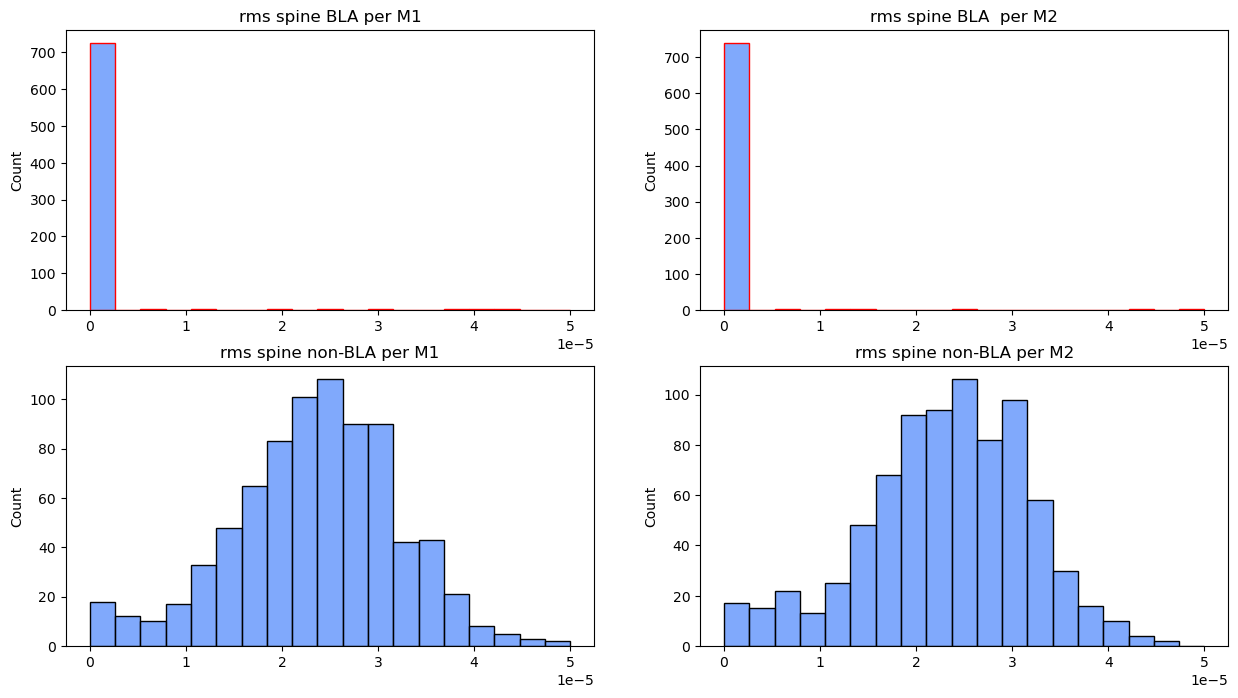

In [100]:
bins_n= np.linspace(0,5e-5,20)
fig, ax = plt.subplots(2,2, figsize=(15, 8))
#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')

sns.histplot(
    rms_t_BLA_M1,
    bins=bins_n,
    edgecolor='red',
    ax=ax[0,0]
)

sns.histplot(
    rms_t_BLA_M2,
    bins=bins_n,
    edgecolor='red',
    ax=ax[0,1]
)


sns.histplot(
    rms_t_non_BLA_M1,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,0]
)

sns.histplot(
    rms_t_non_BLA_M2,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,1]
)


ax[0,0].set_title('rms spine BLA per M1')
ax[0,1].set_title('rms spine BLA  per M2')
ax[1,0].set_title('rms spine non-BLA per M1')
ax[1,1].set_title('rms spine non-BLA per M2')
#ax[0].set_xlabel('pesi')
#ax[1].set_xlabel('pesi')
plt.show()

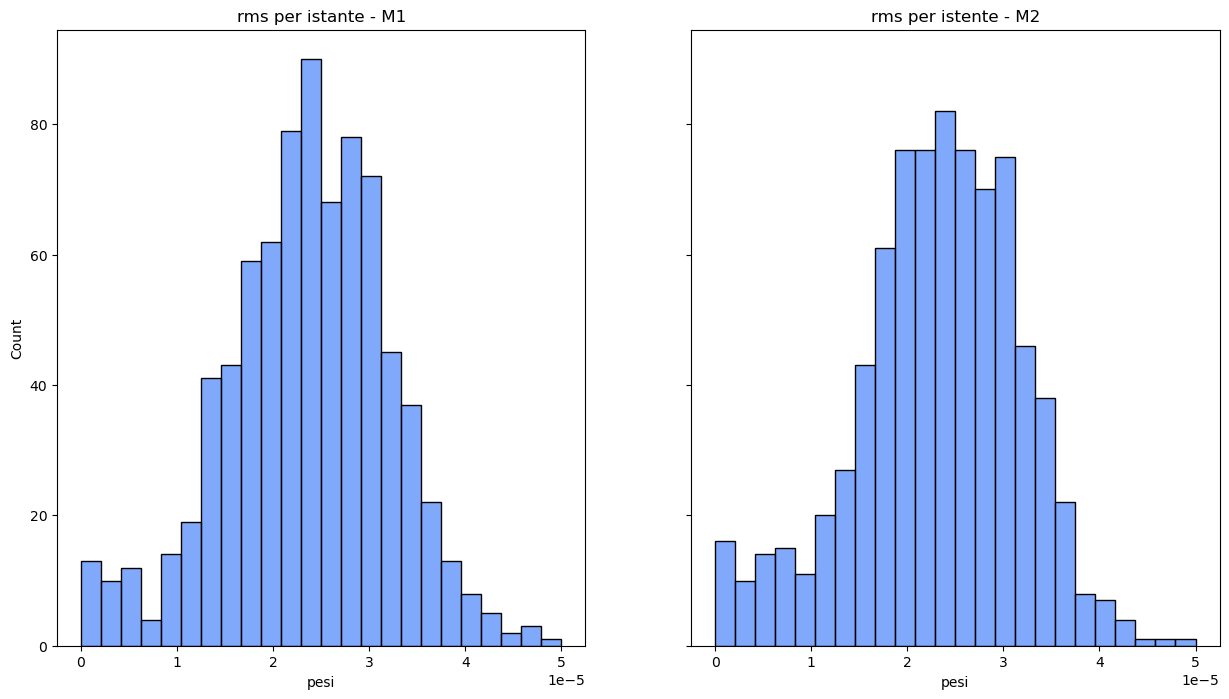

In [101]:
bins_n= np.linspace(0,5e-5,25)
fig, ax = plt.subplots(1,2, figsize=(15, 8),
                       sharex=True, sharey=True)
#ax[0].hist(rms_per_spina_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_per_spina_M2, bins=bins_n, edgecolor='black')
sns.histplot(
    rms_per_istante_M1,
    bins=bins_n,
    edgecolor='black',
    ax=ax[0]
)

sns.histplot(
    rms_per_istante_M2,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1]
)
ax[0].set_title('rms per istante - M1')
ax[1].set_title('rms per istente - M2')

ax[0].set_xlabel('pesi')
ax[1].set_xlabel('pesi')

plt.show()

## Provo a fare un confronto tra i pesi associati alle spine sui compartimenti apical rispetto ai pesi associati alle spine sui compartimenti basal

In [102]:
# ----- per stampare gli indici delle spine che sono su apic[21]
comp = 'basal[20]'
indices = exp_dataset['spines_df'].index[
    exp_dataset['spines_df']['NEURON_compartment_name'] == comp
]
type(indices)
#ind = np.array(indices)
#ind

pandas.core.indexes.base.Index

In [103]:
# exp_dataset['sections_df']['section_name']#['NEURON_compartment_name']
# apic vanno da 0 a 24 e basal da 0 a 22
all_apic_ind = []
for i in range(0,25):
    comp_name = 'apic[' + str(i) + ']'
    indices = exp_dataset['spines_df'].index[
    exp_dataset['spines_df']['NEURON_compartment_name'] == comp_name
    ]
    np.array(indices)
    all_apic_ind.append(indices)

# ----- prendo tutti gli id delle spine che si trovano sui compartimenti apical
all_apic_ind_arr = np.concatenate(all_apic_ind)
del indices

all_basal_ind = []
for i in range(0,23):
    comp_name = 'basal[' + str(i) + ']'
    indices = exp_dataset['spines_df'].index[
    exp_dataset['spines_df']['NEURON_compartment_name'] == comp_name
    ]
    np.array(indices)
    all_basal_ind.append(indices)

# ----- prendo tutti gli id delle spine che si trovano sui compartimento basal
all_basal_ind_arr = np.concatenate(all_basal_ind)


In [104]:
rms_apic_ind_M1 = np.sqrt(np.mean(M1[0][all_apic_ind_arr, :]**2,axis=1)) # ottengo un valore per ciascuna spina, considera gli elementi su una riga quindi che fanno
rms_apic_ind_M2 = np.sqrt(np.mean(M2[0][all_apic_ind_arr, :]**2,axis=1)) # ottengo un valore per ciascuna spina, considera gli elementi su una riga quindi che fanno

rms_basal_ind_M1 = np.sqrt(np.mean(M1[0][all_basal_ind_arr, :]**2,axis=1))
rms_basal_ind_M2 = np.sqrt(np.mean(M2[0][all_basal_ind_arr, :]**2,axis=1))



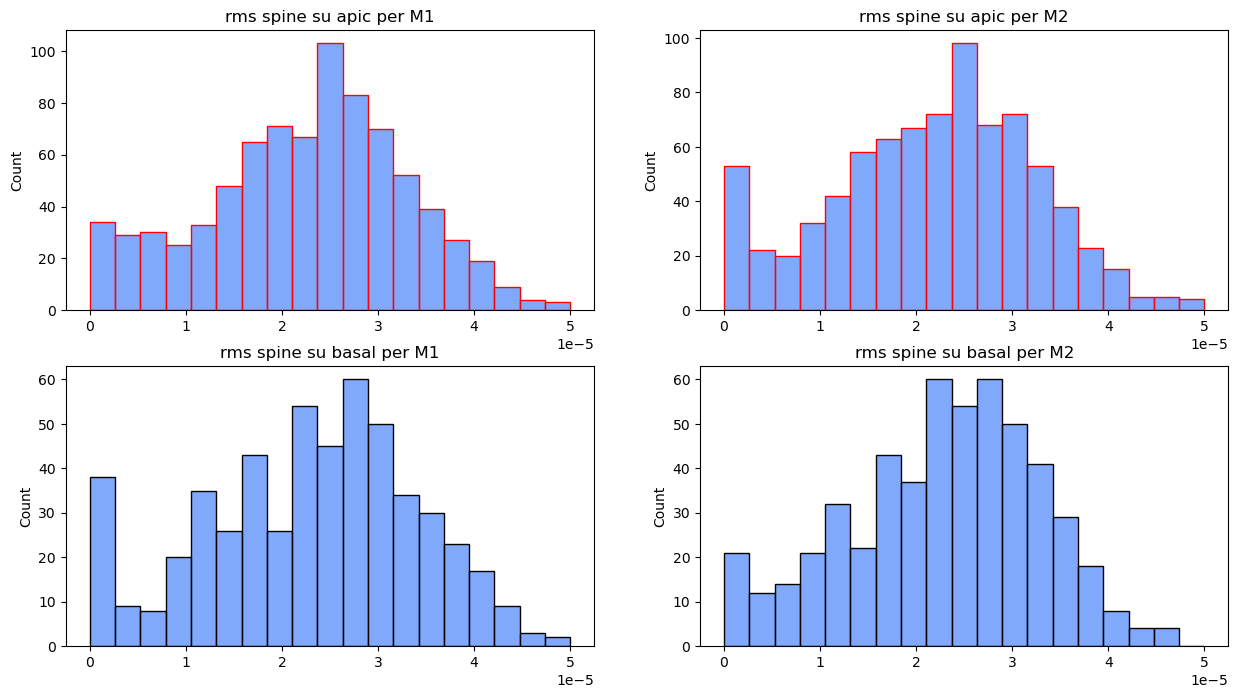

In [105]:
bins_n= np.linspace(0,5e-5,20)
fig, ax = plt.subplots(2,2, figsize=(15, 8))
#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')

sns.histplot(
    rms_apic_ind_M1,
    bins=bins_n,
    edgecolor='red',
    ax=ax[0,0]
)

sns.histplot(
    rms_apic_ind_M2,
    bins=bins_n,
    edgecolor='red',
    ax=ax[0,1]
)

sns.histplot(
    rms_basal_ind_M1,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,0]
)

sns.histplot(
    rms_basal_ind_M2,
    bins=bins_n,
    edgecolor='black',
    ax=ax[1,1]
)


ax[0,0].set_title(f'rms spine su apic per M1')
ax[0,1].set_title(f'rms spine su apic per M2')
ax[1,0].set_title('rms spine su basal per M1')
ax[1,1].set_title('rms spine su basal per M2')
#ax[0].set_xlabel('pesi')
#ax[1].set_xlabel('pesi')
plt.show()

In [106]:
rms_all_apic_M1 = np.sqrt(np.mean(M1[0][all_apic_ind_arr, :]**2))
rms_all_basal_M1 = np.sqrt(np.mean(M1[0][all_basal_ind_arr, :]**2))

rms_all_apic_M2 = np.sqrt(np.mean(M2[0][all_apic_ind_arr, :]**2))
rms_all_basal_M2 = np.sqrt(np.mean(M2[0][all_basal_ind_arr, :]**2))

rms_all_apic_M8 = np.sqrt(np.mean(M8[0][all_apic_ind_arr, :]**2))
rms_all_basal_M8 = np.sqrt(np.mean(M8[0][all_basal_ind_arr, :]**2))

rms_all_apic_M6 = np.sqrt(np.mean(M6[0][all_apic_ind_arr, :]**2))
rms_all_basal_M6 = np.sqrt(np.mean(M6[0][all_basal_ind_arr, :]**2))


rms_all_apic_M3 = np.sqrt(np.mean(M3[0][all_apic_ind_arr, :]**2))
rms_all_basal_M3 = np.sqrt(np.mean(M3[0][all_basal_ind_arr, :]**2))


In [107]:
print('rms all apic/ rms all basal  ')

print('M1:' ,rms_all_apic_M1/rms_all_basal_M1, '\n',
      'M6:', rms_all_apic_M6/rms_all_basal_M6,'\n \n',
      'M2:',rms_all_apic_M2/rms_all_basal_M2, '\n',
      'M3:', rms_all_apic_M3/rms_all_basal_M3, '\n  \n',
      'M8:',rms_all_apic_M8/rms_all_basal_M8, '\n')

rms all apic/ rms all basal  
M1: 0.9704396121673887 
 M6: 0.9778924966982104 
 
 M2: 0.9651588393236881 
 M3: 1.0101954331970415 
  
 M8: 1.0088750229983678 



## Cerco id spine che corrispondono ad apical o basal per un certo branch degree

### 1. Branch degree = 3

In [108]:
ed = exp_dataset['spines_df']

sp_ind_apic_lev3 = np.array(
    ed.loc[
    (ed["branch_degree"] == 3) &
    (ed["compartment"] == 'apical dendrite')
].index
)
sp_ind_bas_lev3 = np.array(
    ed.loc[
    (ed["branch_degree"] == 3) &
    (ed["compartment"] == 'basal dendrite')
].index
)



In [109]:
rms_apic_lev3_M1 = np.sqrt(np.mean(M1[0][sp_ind_apic_lev3, :]**2,axis=1))
rms_apic_lev3_M8 = np.sqrt(np.mean(M8[0][sp_ind_apic_lev3, :]**2,axis=1))
rms_apic_lev3_M2 = np.sqrt(np.mean(M2[0][sp_ind_apic_lev3, :]**2,axis=1))
rms_apic_lev3_M3 = np.sqrt(np.mean(M3[0][sp_ind_apic_lev3, :]**2,axis=1))


rms_bas_lev3_M1 = np.sqrt(np.mean(M1[0][sp_ind_bas_lev3, :]**2,axis=1))
rms_bas_lev3_M8 = np.sqrt(np.mean(M8[0][sp_ind_bas_lev3, :]**2,axis=1))
rms_bas_lev3_M2 = np.sqrt(np.mean(M2[0][sp_ind_bas_lev3, :]**2,axis=1))
rms_bas_lev3_M3 = np.sqrt(np.mean(M3[0][sp_ind_bas_lev3, :]**2,axis=1))




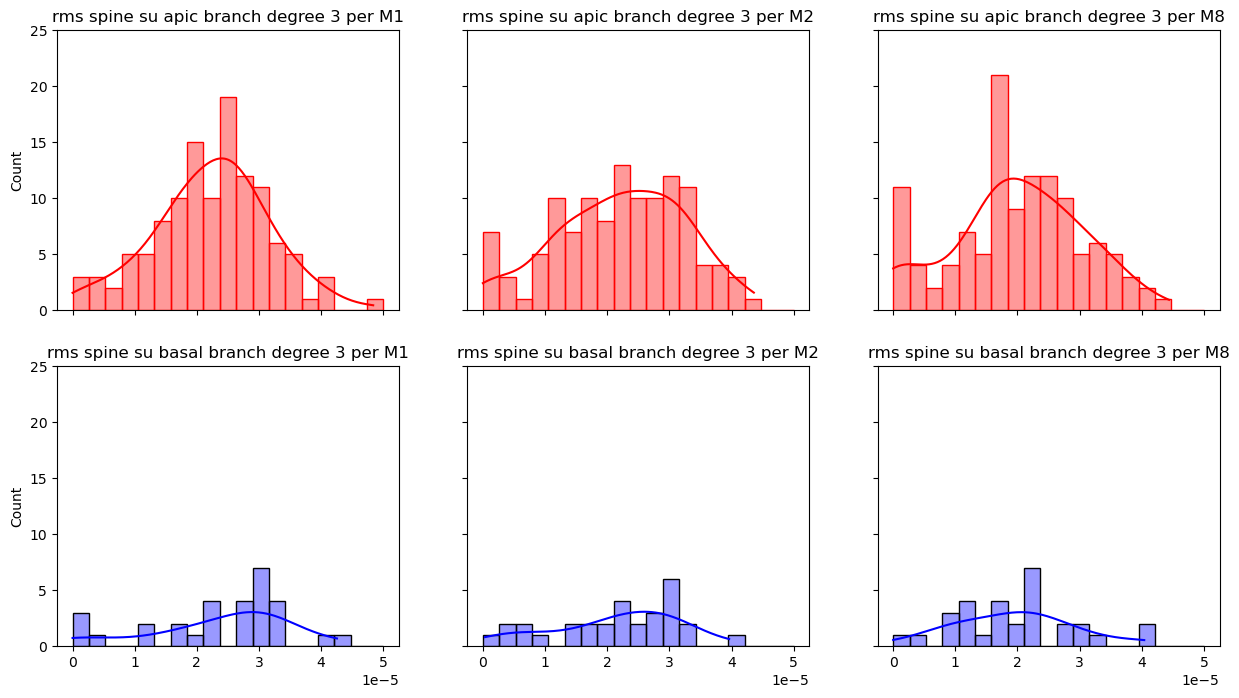

In [110]:
bins_n= np.linspace(0,5e-5,20)
fig, ax = plt.subplots(2,3, figsize=(15, 8),sharex=True,sharey=True)
#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')

sns.histplot(
    rms_apic_lev3_M1,
    bins=bins_n,
    edgecolor='red',color='red', alpha=0.4,
    kde=True,
    ax=ax[0,0]
)

sns.histplot(
    rms_apic_lev3_M2,
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,1]
)

sns.histplot(
    rms_apic_lev3_M8,
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,2]
)

sns.histplot(
    rms_bas_lev3_M1,
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,0]
)

sns.histplot(
    rms_bas_lev3_M2,
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,1]
)

sns.histplot(
    rms_bas_lev3_M8,
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,2]
)



ax[0,0].set_ylim([0,25])
ax[0,1].set_ylim([0,25])

ax[0,0].set_title(f'rms spine su apic branch degree 3 per M1')
ax[0,1].set_title(f'rms spine su apic branch degree 3 per M2')
ax[1,0].set_title('rms spine su basal branch degree 3 per M1')
ax[1,1].set_title('rms spine su basal branch degree 3 per M2')

ax[0,2].set_title(f'rms spine su apic branch degree 3 per M8')
ax[1,2].set_title('rms spine su basal branch degree 3 per M8')
#ax[0].set_xlabel('pesi')
#ax[1].set_xlabel('pesi')
plt.show()

### 2. Branch degree = 2

In [111]:
ed = exp_dataset['spines_df']

sp_ind_apic_lev2 = np.array(
    ed.loc[
    (ed["branch_degree"] == 2) &
    (ed["compartment"] == 'apical dendrite')
].index
)
sp_ind_bas_lev2 = np.array(
    ed.loc[
    (ed["branch_degree"] == 2) &
    (ed["compartment"] == 'basal dendrite')
].index
)
sp_ind_bas_lev2


array([ 111,  112,  113,  151,  152,  153,  169,  170,  171,  172,  176,
        177,  178,  179,  180,  181,  182,  183,  184,  185,  186,  187,
        188,  189,  192,  210,  211,  212,  213,  251,  252,  253,  254,
        328,  329,  405,  406,  407,  408,  409,  421,  422,  423,  424,
        425,  426,  427,  461,  462,  463,  464,  465,  466,  467,  468,
        469,  470,  471,  472,  473,  474,  475,  476,  477,  478,  479,
        480,  481,  482,  483,  484,  485,  486,  487,  488,  489,  490,
        491,  511,  512,  513,  514,  515,  516,  517,  518,  519,  520,
        541,  542,  543,  544,  545,  546,  547,  548,  549,  550,  551,
        552,  553,  554,  555,  556,  557,  558,  559,  560,  561,  562,
        603,  604,  605,  606,  607,  608,  609,  644,  645,  646,  647,
        648,  649,  650,  651,  654,  655,  684,  685,  686,  687,  690,
        691,  692,  693,  694,  695,  696,  697,  736,  737,  738,  739,
        740,  741,  742,  743,  744,  778,  779,  7

In [112]:
Ms = {
    "M1": M1,
    "M2": M2,
    "M3": M3,
    "M6": M6,
    "M8": M8,
    "M10": M10
}

rms_apic_lev2 = {}
rms_bas_lev2 = {}

for name, M in Ms.items():

    rms_apic_lev2[name] = np.sqrt(
        np.mean(M[0][sp_ind_apic_lev2, :]**2, axis=1)
    )

    rms_bas_lev2[name] = np.sqrt(
        np.mean(M[0][sp_ind_bas_lev2, :]**2, axis=1)
    )


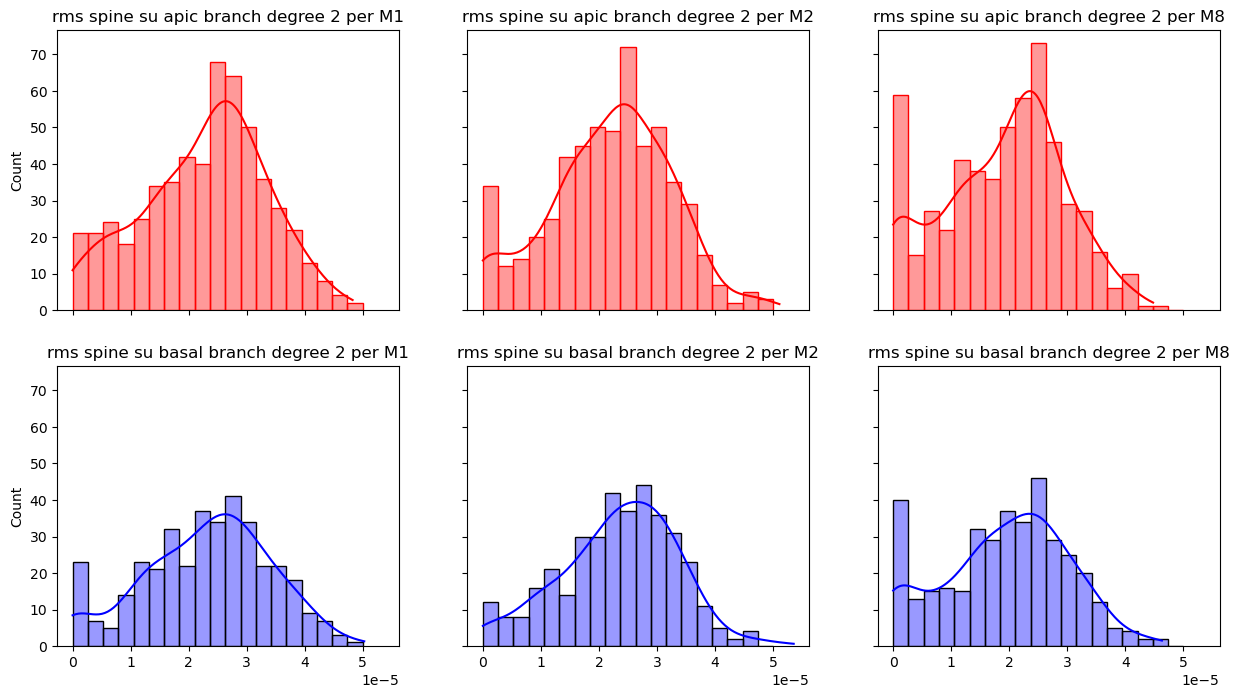

In [113]:
bins_n= np.linspace(0,5e-5,20)
fig, ax = plt.subplots(2,3, figsize=(15, 8),sharex=True,sharey=True)
#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')

sns.histplot(
    rms_apic_lev2['M1'],
    bins=bins_n,
    edgecolor='red',color='red', alpha=0.4,
    kde=True,
    ax=ax[0,0]
)

sns.histplot(
    rms_apic_lev2['M2'],
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,1]
)

sns.histplot(
    rms_apic_lev2['M8'],
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,2]
)

sns.histplot(
    rms_bas_lev2['M1'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,0]
)

sns.histplot(
    rms_bas_lev2['M2'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,1]
)

sns.histplot(
    rms_bas_lev2['M8'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,2]
)



#ax[0,0].set_ylim([0,25])
#ax[0,1].set_ylim([0,25])

ax[0,0].set_title(f'rms spine su apic branch degree 2 per M1')
ax[0,1].set_title(f'rms spine su apic branch degree 2 per M2')
ax[1,0].set_title('rms spine su basal branch degree 2 per M1')
ax[1,1].set_title('rms spine su basal branch degree 2 per M2')

ax[0,2].set_title(f'rms spine su apic branch degree 2 per M8')
ax[1,2].set_title('rms spine su basal branch degree 2 per M8')
#ax[0].set_xlabel('pesi')
#ax[1].set_xlabel('pesi')
plt.show()

### 3. Branch degree =1

In [114]:
ed = exp_dataset['spines_df']

sp_ind_apic_lev1 = np.array(
    ed.loc[
    (ed["branch_degree"] == 1) &
    (ed["compartment"] == 'apical dendrite')
].index
)
sp_ind_bas_lev1 = np.array(
    ed.loc[
    (ed["branch_degree"] == 1) &
    (ed["compartment"] == 'basal dendrite')
].index
)



In [115]:
rms_apic_lev1 = {}
rms_bas_lev1 = {}

for name, M in Ms.items():

    rms_apic_lev1[name] = np.sqrt(
        np.mean(M[0][sp_ind_apic_lev1, :]**2, axis=1)
    )

    rms_bas_lev1[name] = np.sqrt(
        np.mean(M[0][sp_ind_bas_lev1, :]**2, axis=1)
    )


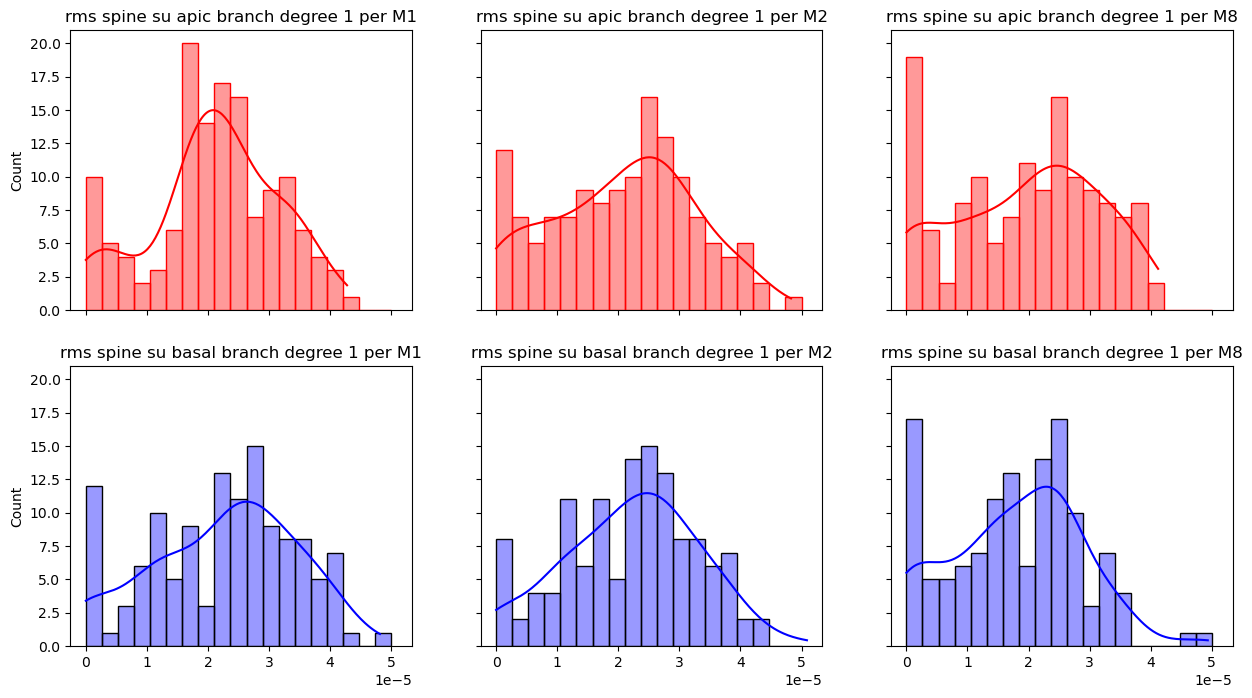

In [116]:
bins_n= np.linspace(0,5e-5,20)
fig, ax = plt.subplots(2,3, figsize=(15, 8),sharex=True,sharey=True)
#ax[0].hist(rms_BLA_attivate_M1, bins=bins_n,edgecolor='black')
#ax[1].hist(rms_BLA_attivate_M2, bins=bins_n, edgecolor='black')

sns.histplot(
    rms_apic_lev1['M1'],
    bins=bins_n,
    edgecolor='red',color='red', alpha=0.4,
    kde=True,
    ax=ax[0,0]
)

sns.histplot(
    rms_apic_lev1['M2'],
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,1]
)

sns.histplot(
    rms_apic_lev1['M8'],
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,2]
)

sns.histplot(
    rms_bas_lev1['M1'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,0]
)

sns.histplot(
    rms_bas_lev1['M2'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,1]
)

sns.histplot(
    rms_bas_lev1['M8'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,2]
)
'''
sns.histplot(
    rms_apic_lev1['M10'],
    bins=bins_n,
    edgecolor='red',color='red',alpha=0.4,
    kde=True,
    ax=ax[0,3]
)

sns.histplot(
    rms_bas_lev1['M10'],
    bins=bins_n,
    edgecolor='black',color='blue',alpha=0.4,
    kde=True,
    ax=ax[1,3]
)
'''

#ax[0,0].set_ylim([0,25])
#ax[0,1].set_ylim([0,25])

ax[0,0].set_title(f'rms spine su apic branch degree 1 per M1')
ax[0,1].set_title(f'rms spine su apic branch degree 1 per M2')
ax[1,0].set_title('rms spine su basal branch degree 1 per M1')
ax[1,1].set_title('rms spine su basal branch degree 1 per M2')

ax[0,2].set_title(f'rms spine su apic branch degree 1 per M8')
ax[1,2].set_title('rms spine su basal branch degree 1 per M8')
#ax[0].set_xlabel('pesi')
#ax[1].set_xlabel('pesi')
plt.show()

### Voglio vedere i $V_m$

In [36]:
import pandas as pd
df = pd.read_pickle("D:/dataset_M1_M20_30_08_2026.pkl")

In [47]:
SpineType = 'BLA'
MainMatrixID = 'M2'
SimType = 'random'

aus_data = df.loc[
                (df["spine_type"] == SpineType) &
                (df["main_matrix_id"] == MainMatrixID) &
                (df["condition"] == SimType)
            ]

time = np.arange(0,800+ 0.025,0.025)

import matplotlib.pyplot as plt
import numpy as np
import os

# cartella dove salvare le figure
os.makedirs("D:/figures_02_09_2026", exist_ok=True)

n_per_figura = 25
n_righe = 5
n_colonne = 5

n_vm = len(aus_data['data'])

for start in range(0, n_vm, n_per_figura):

    # nuova figura 5x5
    fig, axes = plt.subplots(
        n_righe,
        n_colonne,
        figsize=(15, 12)
    )

    # trasformo gli axes in un array 1D
    axes = axes.flatten()

    # grafici da fare in questa figura
    end = min(start + n_per_figura, n_vm)

    for j, i in enumerate(range(start, end)):

        V = aus_data['data'].iloc[i]

        axes[j].plot(time,V)
        axes[j].set_title(f"i = {i}")
        axes[j].set_xlabel("time (ms)")
        axes[j].set_ylabel("$V_m$")
        #axes[j].ylim([-70, 30])
        axes[j].grid(True)

    # se l'ultima figura non ha 25 grafici,
    # nascondo i subplot vuoti
    for j in range(end - start, n_per_figura):
        axes[j].axis("off")

    fig.tight_layout()

    # numero della figura: 0, 1, 2, ...
    numero_figura = start // n_per_figura

    fig.savefig(
        f"D:/figures_02_09_2026/Vm_{SpineType}_{MainMatrixID}_{SimType}_{numero_figura:02d}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)
